In [2]:
from pathlib import Path
import os 
from dataclasses import dataclass
import yaml

from tqdm.notebook import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
import seaborn as sns

import sys
sys.path.append('../../')
sys.path.append('../')

from src import mod_cog_tasks as mct 
from src import mod_cog_data_utils as mcdu
from src import eg_utils
from src import analysis_utils as au
from src import plot_utils as pu

from train_mod_cog import RNNModel

device = eg_utils.get_device()

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


['/home/mila/p/pingsheng.li/projects/eg_rnns/mod_cog/analysis/arial.ttf']
/home/mila/p/pingsheng.li/projects/eg_rnns/mod_cog/analysis/arial.ttf
/home/mila/p/pingsheng.li/projects/eg_rnns/mod_cog/analysis/arial.ttf


In [2]:
%load_ext autoreload
%autoreload 2

# Defining folders with experiments 

In [3]:
# scratch = Path(os.environ['SCRATCH'])
# os.listdir(scratch/"eg_paper/mod_cog/")
# results_dir = scratch/"eg_paper/mod_cog/exp8_final_combined"
results_dir = Path(os.path.join(os.environ['SCRATCH'], "eg_paper/mod_cog/exp8_final_combined_with_cgd"))
# results_dir = Path("/network/projects/_groups/linclab_users/eg/modcog/exp8_final_combined")
os.listdir(results_dir)

['eg_N2500_lr3.5_m0.925_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss',
 'eg_N2500_lr3.5_m0.925_wd1e-06_mxgn2.0_init_normal_a1.0_lrsched_custom_loss',
 'eg_N2500_lr3.5_m0.925_wd1e-06_mxgn2.0_init_uniform_a1.0_lrsched_custom_loss',
 'eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss',
 'eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_normal_a1.0_lrsched_custom_loss',
 'eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_uniform_a1.0_lrsched_custom_loss',
 'eg_unsigned_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_normal_a1.0_lrsched_custom_loss',
 'eg_unsigned_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_uniform_a1.0_lrsched_custom_loss',
 'eg_unsigned_N2500_lr0.1_m0.925_wd1e-07_mxgn2.0_init_normal_a1.0_lrsched_custom_loss',
 'eg_unsigned_N2500_lr0.1_m0.925_wd1e-07_mxgn2.0_init_uniform_a1.0_lrsched_custom_loss',
 'eg_unsigned_N2500_lr1.0_m0.925_wd1e-06_mxgn2.0_init_normal_a1.0_lrsched_custom_loss',
 'eg_unsigned_N2500_lr1.0_m0.925_wd1e-06_mxgn2.0_init_uniform_a1.0_l

In [4]:
# Comparing 1e-7 eg, 1e-6 gd weight decays
exp_names = []
for exp_name in os.listdir(results_dir):
    if exp_name.startswith("eg"):
        if "1e-07" in exp_name:exp_names.append(exp_name)
    elif exp_name.startswith("eg_unsigned"):
        if "1e-07" in exp_name:exp_names.append(exp_name)
    elif exp_name.startswith("gd"):
        if "1e-06" in exp_name:exp_names.append(exp_name)
    elif exp_name.startswith("cgd"):
        if "1e-06" in exp_name:exp_names.append(exp_name)
print(exp_names)

['eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss', 'eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_normal_a1.0_lrsched_custom_loss', 'eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_uniform_a1.0_lrsched_custom_loss', 'eg_unsigned_N2500_lr0.1_m0.925_wd1e-07_mxgn2.0_init_normal_a1.0_lrsched_custom_loss', 'eg_unsigned_N2500_lr0.1_m0.925_wd1e-07_mxgn2.0_init_uniform_a1.0_lrsched_custom_loss', 'eg_unsigned_N2500_lr1.0_m0.925_wd1e-07_mxgn2.0_init_normal_a1.0_lrsched_custom_loss', 'eg_unsigned_N2500_lr1.0_m0.925_wd1e-07_mxgn2.0_init_uniform_a1.0_lrsched_custom_loss', 'eg_unsigned_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_normal_a1.0_lrsched_custom_loss', 'eg_unsigned_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_uniform_a1.0_lrsched_custom_loss', 'gd_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss', 'gd_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_normal_a1.0_lrsched_custom_loss', 'gd_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_uniform_a1.0_lrsched_cust

In [5]:
# reformat exp_names above for use as a key for results dict
# for example: eg_log_normal from eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss
def format_exp_as_key(exp_name):
    if exp_name.startswith("eg_unsigned"):
        s = "eg_unsigned"
    elif exp_name.startswith("cgd"):
        s = "cgd"
    else:
        s = exp_name[:2]
    if "log_normal" in exp_name:
        s += "_log_normal"
    elif "normal" in exp_name:
        s += "_normal"
    elif "uniform" in exp_name:
        s += "_uniform"
    return s

exp_folders = au.DotDict({format_exp_as_key(f):results_dir/f for f in exp_names})
print(exp_folders)
results_dict = au.load_results(exp_folders)
# Stack results across all seeds for each experiment
for exp_name in results_dict.keys():
    results_dict[exp_name] = au.concat_seed_results(results_dict[exp_name])

{'eg_log_normal': PosixPath('/network/scratch/p/pingsheng.li/eg_paper/mod_cog/exp8_final_combined_with_cgd/eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss'), 'eg_normal': PosixPath('/network/scratch/p/pingsheng.li/eg_paper/mod_cog/exp8_final_combined_with_cgd/eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_normal_a1.0_lrsched_custom_loss'), 'eg_uniform': PosixPath('/network/scratch/p/pingsheng.li/eg_paper/mod_cog/exp8_final_combined_with_cgd/eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_uniform_a1.0_lrsched_custom_loss'), 'eg_unsigned_normal': PosixPath('/network/scratch/p/pingsheng.li/eg_paper/mod_cog/exp8_final_combined_with_cgd/eg_unsigned_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_normal_a1.0_lrsched_custom_loss'), 'eg_unsigned_uniform': PosixPath('/network/scratch/p/pingsheng.li/eg_paper/mod_cog/exp8_final_combined_with_cgd/eg_unsigned_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_uniform_a1.0_lrsched_custom_loss'), 'gd_log_normal': PosixPath('/network/scratch/p/p

In [6]:
# Add colours to exps
# https://www.datylon.com/blog/data-visualization-for-colorblind-readers
results_dict.eg_normal.c = "#fec615" # golden yellow
results_dict.eg_uniform.c = "green" #ff9408" # tangerine
results_dict.eg_log_normal.c = "#f05039" # orangey red

results_dict.gd_log_normal.c = "#1f449c" # blue
results_dict.gd_normal.c = "#8af1fe"
results_dict.gd_uniform.c = "#9e43a2"

results_dict.cgd_log_normal.c = "#0b6623" # dark green

results_dict.eg_unsigned_log_normal.c = "#ff33ff"
results_dict.eg_unsigned_normal.c = "#ff66ff"
results_dict.eg_unsigned_uniform.c = "#ff99ff"

In [7]:
# make the legend
results_dict.keys()

dict_keys(['eg_log_normal', 'eg_normal', 'eg_uniform', 'eg_unsigned_normal', 'eg_unsigned_uniform', 'gd_log_normal', 'gd_normal', 'gd_uniform', 'cgd_log_normal', 'eg_unsigned_log_normal'])

0.9746912956237793 0.001830976838376106 (6000, 5)
0.9742324233055115 0.0010762100035310944 (6000, 5)
0.9742835402488709 0.0014460740781236246 (6000, 5)
0.0 0.0 (6000, 5)


/tmp/ipykernel_3872036/448868024.py:40: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


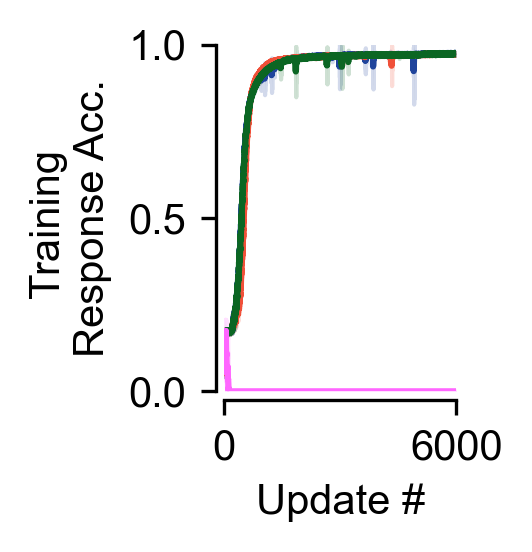

In [7]:
exp_strs = ["gd_log_normal", "eg_log_normal", "cgd_log_normal", "eg_unsigned_normal",]
# exp_strs = ["gd_log_normal", "eg_log_normal", "eg_unsigned_normal",]
key = "Dec Acc"
xlims = (0, 6000)
ylims = (0, 1)

plt.figure(figsize=(1.,1.5), dpi = 300)
for exp_name in exp_strs:
    # print(exp_name)
    # print(results_dict[exp_name].train_results)
    array = results_dict[exp_name].train_results[key].mean(axis=1)
    std_dev = results_dict[exp_name].train_results[key].std(axis=1)
    print(array[-1], std_dev[-1], results_dict[exp_name].train_results[key].shape)
    n_updates = array.shape[0]
    plt.plot(np.arange(1,n_updates+1), array, c=results_dict[exp_name].c, label=exp_name)
    plt.fill_between(np.arange(1,n_updates+1), array-std_dev, array+std_dev, color=results_dict[exp_name].c, alpha=0.2)
ax = plt.gca()

# Set the tick locations
logx = False
logy = False
if logx: plt.xscale("log")
if logy: plt.yscale("log")

y_step = 0.5
x_step = 6000
ax.set_xticks(np.arange(xlims[0],xlims[1]+x_step, x_step))  
ax.set_yticks(np.arange(ylims[0],ylims[1]+y_step, y_step)) 
ax.set_xlim(xlims)
ax.set_ylim(ylims)

# sns.despine(offset=2, trim=True)

plt.xlabel("Update #")
plt.ylabel("Training \nResponse Acc.", rotation=90)

#sns.despine()
sns.despine(offset=2, trim=True)

plt.tight_layout()
plt.savefig("figs/fig1/1c_response_acc.pdf", bbox_inches="tight", transparent=True)
plt.savefig("figs/fig1/1c_decacc_training_uni.png", bbox_inches="tight")

# save the data used to make the plot
data_to_save = {}
for exp_name in exp_strs:
    array = results_dict[exp_name].train_results[key].mean(axis=1)
    std_dev = results_dict[exp_name].train_results[key].std(axis=1)
    data_to_save[exp_name] = {
        "mean": array,
        "std": std_dev
    }
np.savez("plot_data/fig1c_response_acc_data.npz", **data_to_save)

(5,)
0.9839465757608412 4.2723772285107356e-05
(5,)
0.9839160858392717 5.590861774628249e-05
(5,)
0.9838015948534011 5.8444066712415734e-05
(5,)
0.0 0.0
(5,)
(5,)
(5,)
(5,)


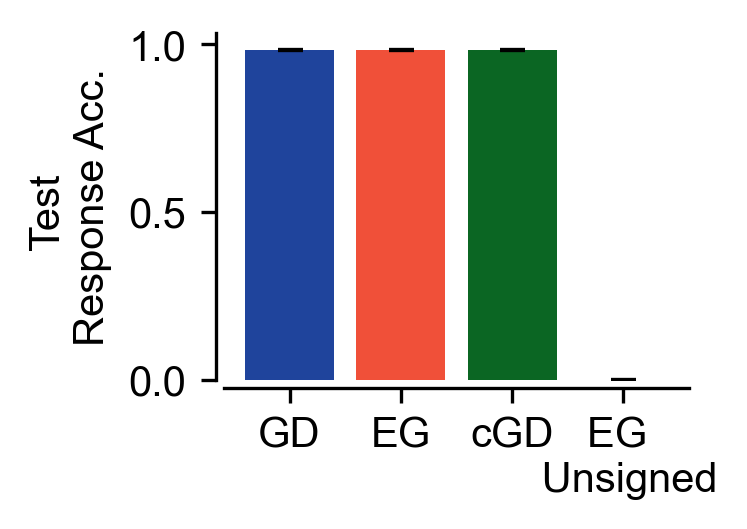

In [8]:
# bar chart showing final accuracy across the different weight distributions

plt.figure(figsize=(2,1.5), dpi = 300)
exp_labels = ["GD", "EG", "cGD", f"EG \n Unsigned"]
colours = [results_dict[exp_str].c for exp_str in exp_strs]
key = "test_Dec_Acc"
means = []
std_devs = []
for exp_name in exp_strs:
    array = results_dict[exp_name].eval_results[key][-1,:] # last epoch, all seeds
    print(array.shape)
    means.append(array.mean())
    std_devs.append(array.std())
    print(array.mean(), array.std())

plt.bar(exp_labels, means, yerr=std_devs, color=colours, capsize=3, width=0.8)
sns.despine(offset=2)

plt.ylabel("Test \nResponse Acc.")

# plt.savefig("figs/fig1/1c_response_acc_test.pdf", bbox_inches="tight", transparent=True)

# save the data used to make the bar plot
data_to_save = {}
for i, exp_name in enumerate(exp_strs):
    array = results_dict[exp_name].eval_results[key][-1,:] # last epoch, all seeds
    print(array.shape)
    mean = array.mean()
    std_dev = array.std()
    data_to_save[exp_name] = {
        "mean": mean,
        "std": std_dev
    }   
np.savez("plot_data/fig1c_response_acc_test_data.npz", **data_to_save)

In [9]:
gd_results = results_dict.gd_log_normal
cgd_results = results_dict.cgd_log_normal
eg_results = results_dict.eg_log_normal

eg = eg_results.train_results["rnn.weight_hh"]['r2']
gd = gd_results.train_results["rnn.weight_hh"]['r2']
cgd = cgd_results.train_results["rnn.weight_hh"]['r2']
# eg = eg_results.train_results["fc.weight"]['r2']
# gd = gd_results.train_results["fc.weight"]['r2']

eg.shape

(6000, 5)

In [13]:
gd_results.eval_results.keys()

dict_keys(['val_Acc', 'val_Dec_Acc', 'val_Loss', 'test_Acc', 'test_Dec_Acc', 'test_Loss'])

/tmp/ipykernel_3872036/890575117.py:3: RuntimeWarning: Mean of empty slice
  plt.plot(np.nanmean(eg, axis=1), color=eg_results.c, label='EG')
/tmp/ipykernel_3872036/890575117.py:5: RuntimeWarning: Mean of empty slice
  np.nanmean(eg, axis=1) - np.nanstd(eg, axis=1),
/network/scratch/p/pingsheng.li/.conda/eg_rnns/lib/python3.9/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_3872036/890575117.py:6: RuntimeWarning: Mean of empty slice
  np.nanmean(eg, axis=1) + np.nanstd(eg, axis=1),
/tmp/ipykernel_3872036/890575117.py:9: RuntimeWarning: Mean of empty slice
  plt.plot(np.nanmean(gd, axis=1), color=gd_results.c, label='GD')
/tmp/ipykernel_3872036/890575117.py:11: RuntimeWarning: Mean of empty slice
  np.nanmean(gd, axis=1) - np.nanstd(gd, axis=1),
/tmp/ipykernel_3872036/890575117.py:12: RuntimeWarning: Mean of empty slice
  np.nanmean(gd, axis=1) + np.nanstd(g

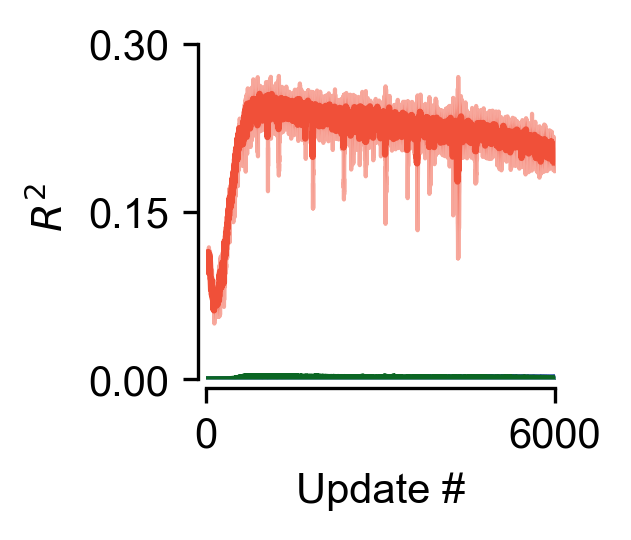

In [10]:
plt.figure(figsize=(1.5,1.5), dpi = 300)

plt.plot(np.nanmean(eg, axis=1), color=eg_results.c, label='EG')
plt.fill_between(np.arange(eg.shape[0]), 
                    np.nanmean(eg, axis=1) - np.nanstd(eg, axis=1),
                    np.nanmean(eg, axis=1) + np.nanstd(eg, axis=1),
                    color=eg_results.c, alpha=0.5)

plt.plot(np.nanmean(gd, axis=1), color=gd_results.c, label='GD')
plt.fill_between(np.arange(gd.shape[0]), 
                    np.nanmean(gd, axis=1) - np.nanstd(gd, axis=1),
                    np.nanmean(gd, axis=1) + np.nanstd(gd, axis=1),
                    color=gd_results.c, alpha=0.5)

plt.plot(np.nanmean(cgd, axis=1), color=cgd_results.c, label='cGD')
plt.fill_between(np.arange(cgd.shape[0]), 
                    np.nanmean(cgd, axis=1) - np.nanstd(cgd, axis=1),
                    np.nanmean(cgd, axis=1) + np.nanstd(cgd, axis=1),
                    color=cgd_results.c, alpha=0.5)

plt.ylabel(r'$R^2$')
plt.xlabel('Update #')  

ax = plt.gca()
xlims = (0, 6000)
ylims = (0, 0.31)
y_step = 0.15
x_step = 6000
ax.set_xticks(np.arange(xlims[0],xlims[1]+x_step, x_step))  
ax.set_yticks(np.arange(ylims[0],ylims[1]+y_step, y_step)) 
ax.set_xlim(xlims)
ax.set_ylim(ylims)

sns.despine(offset=2, trim=True)
plt.savefig("figs/fig1/1g_r2.pdf", bbox_inches="tight", transparent=True)

# save the data used to make the plot
data_to_save = {}
for exp_name, r2_array in zip(["eg_log_normal", "gd_log_normal", "cgd_log_normal"], [eg, gd, cgd]):
    mean_r2 = np.nanmean(r2_array, axis=1)
    std_r2 = np.nanstd(r2_array, axis=1)
    data_to_save[exp_name] = {
        "mean": mean_r2,
        "std": std_r2
    }
np.savez("plot_data/fig1g_r2_data.npz", **data_to_save)



In [11]:
# sign flips

gd_results = results_dict.gd_log_normal
cgd_results = results_dict.cgd_log_normal
eg_results = results_dict.eg_log_normal

eg = eg_results.train_results["rnn.base_layer.weight_hh_sflips"] # tiny bug here, didn't remove base_layer name in training
gd = gd_results.train_results["rnn.weight_hh_sflips"]
cgd = cgd_results.train_results["rnn.weight_hh_sflips"]

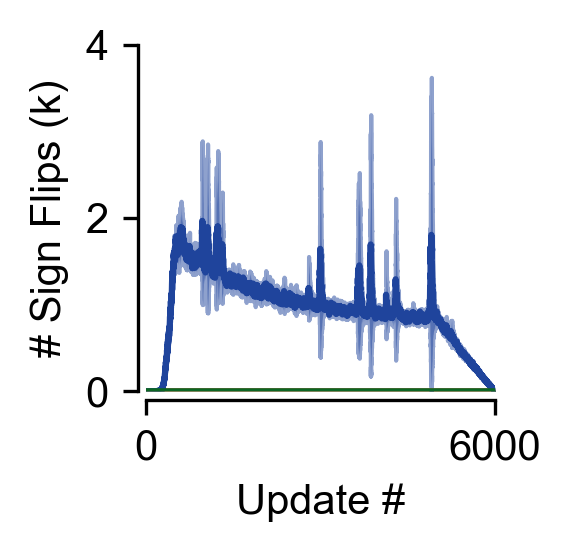

In [12]:
plt.figure(figsize=(1.5,1.5), dpi = 300)

plt.plot(np.nanmean(eg, axis=1), color=eg_results.c, label='EG')
plt.fill_between(np.arange(eg.shape[0]), 
                    np.nanmean(eg, axis=1) - np.nanstd(eg, axis=1),
                    np.nanmean(eg, axis=1) + np.nanstd(eg, axis=1),
                    color=eg_results.c, alpha=0.5)

plt.plot(np.nanmean(gd, axis=1), color=gd_results.c, label='GD')
plt.fill_between(np.arange(gd.shape[0]), 
                    np.nanmean(gd, axis=1) - np.nanstd(gd, axis=1),
                    np.nanmean(gd, axis=1) + np.nanstd(gd, axis=1),
                    color=gd_results.c, alpha=0.5)

plt.plot(np.nanmean(cgd, axis=1), color=cgd_results.c, label='cGD')
plt.fill_between(np.arange(cgd.shape[0]), 
                    np.nanmean(cgd, axis=1) - np.nanstd(cgd, axis=1),
                    np.nanmean(cgd, axis=1) + np.nanstd(cgd, axis=1),
                    color=cgd_results.c, alpha=0.5)

plt.ylabel('# Sign Flips (k)')
plt.xlabel('Update #')  

ax = plt.gca()
xlims = (0, 6000)
ylims = (0, 4000)
y_step = 2000
x_step = 6000
ax.set_xticks(np.arange(xlims[0],xlims[1]+x_step, x_step))  
yticks = np.arange(ylims[0],ylims[1]+y_step, y_step)
ylabels = [int(int(s)/1000) for s in yticks]
ax.set_yticks(yticks, labels=ylabels) 
ax.set_xlim(xlims)
ax.set_ylim(ylims)

sns.despine(offset=2, trim=True)
plt.savefig("figs/fig1/1f_sign_flips.pdf", bbox_inches="tight", transparent=True)

# save the data used to make the plot
data_to_save = {}
for exp_name, sflips_array in zip(["eg_log_normal", "gd_log_normal", "cgd_log_normal"], [eg, gd, cgd]):
    mean_sflips = np.nanmean(sflips_array, axis=1)
    std_sflips = np.nanstd(sflips_array, axis=1)
    data_to_save[exp_name] = {
        "mean": mean_sflips,
        "std": std_sflips
    }
np.savez("plot_data/fig1f_sign_flips_data.npz", **data_to_save)

## Plot weight  histograms



In [13]:
from scipy.stats import norm

def get_norm_pdf(points, mean, std):
    return norm(loc=mean, scale=std).pdf(points)

def get_checkpoint_name(results, seed, epoch_idx):
    return str(results[seed].epoch_ckpts[0]).split('model_')[0] + f'model_{epoch_idx}.pt'


def plot_weight_hists(eg_exp_results, gd_exp_results, eg_key="rnn.base_layer.weight_hh", epoch_idx=6,
                      zero_th=None, log_weights=False, log_y_scale=False, kde=False, stat='proportion',
                     gaussian_approx=False, seperate_plots=True, xlims_step=None, ylims_step=None, 
                      figsize_tuple=None, axis_off=False):
    print("Todo: suppress / correct warnings!")
    if figsize_tuple is None: 
        figsize_tuple = (1.5,1.5)
    fig = plt.figure(figsize=figsize_tuple, dpi = 300)
    for seed in ["seed_7"]:#,"seed_6","seed_7","seed_8","seed_9"]:
        #plt.title(seed)
        print(type(fig))
        if seperate_plots:
            # Add an axes to the figure at position [left, bottom, width, height]
            # ax_eg = fig.add_axes([0.1, 0.1, 0.4, 1])
            # ax_gd = fig.add_axes([0.6, 0.1, 0.4, 1])
            ax_eg = fig.add_axes([0.0, 0., 0.8, .4])
            ax_gd = fig.add_axes([0.0, 0.5, 0.8, .4])
        else:
            ax_eg = fig.add_subplot(111)
            ax_gd = ax_eg

        gd_ckpt = torch.load(get_checkpoint_name(gd_exp_results, seed, epoch_idx),
                             map_location=torch.device('cpu'))
        eg_ckpt = torch.load(get_checkpoint_name(eg_exp_results, seed, epoch_idx),
                             map_location=torch.device('cpu'))
        # cgd_ckpt = torch.load(get_checkpoint_name(cgd_exp_results, seed, epoch_idx),
        #                      map_location=torch.device('cpu'))
        print(str(eg_exp_results[seed].epoch_ckpts[0]).split('model_')[0] + f'model_{epoch_idx}.pt')
        
        gd_key = eg_key.replace("base_layer.", "")

        gd_arr = gd_ckpt[gd_key].flatten().detach().numpy()
        eg_arr = eg_ckpt[eg_key].flatten().detach().numpy()

        gd_arr = np.abs(gd_arr)
        eg_arr = np.abs(eg_arr)
        
        if zero_th is not None:
            gd_arr = gd_arr[gd_arr > zero_th]
            eg_arr = eg_arr[eg_arr > zero_th]
        if log_weights:
            gd_arr = np.log(gd_arr)
            eg_arr = np.log(eg_arr)
    #     gd_arr = np.where(np.isinf(gd_arr), np.nan, gd_arr)
    #     eg_arr = np.where(np.isinf(eg_arr), np.nan, eg_arr)

#         print(f"GD: std {np.std(gd_arr)}, skew {stats.skew(gd_arr)}, kurtosis  {stats.kurtosis(gd_arr)}")
#         print(f"EG: std {np.std(eg_arr)}, skew {stats.skew(eg_arr)}, kurtosis  {stats.kurtosis(eg_arr)}")
        max_weight = np.max([np.max(eg_arr), np.max(gd_arr)])
        bin_edges = np.linspace(min(0, np.min([np.min(eg_arr), np.min(gd_arr)])), max_weight, 50)

        sns.histplot(eg_arr, bins = bin_edges, kde=kde, stat=stat, color=eg_exp_results.c, ec=None,
                    label='EG', ax=ax_eg)
        
        if gaussian_approx:
            points = np.linspace(min(0, np.min([np.min(eg_arr), np.min(gd_arr)])), max_weight, 500)
            ax_eg.plot(points, get_norm_pdf(points, eg_arr.mean(), eg_arr.std()), color=eg_exp_results.c,
                    linestyle='--')
        
        sns.histplot(gd_arr, bins = bin_edges, kde=kde, stat=stat, color=gd_exp_results.c, ec=None, alpha=0.5,
                    label='GD', ax=ax_gd)
        
        if gaussian_approx:
            points = np.linspace(min(0, np.min([np.min(eg_arr), np.min(gd_arr)])), max_weight, 500)
            ax_gd.plot(points, get_norm_pdf(points, gd_arr.mean(), gd_arr.std()), color=gd_exp_results.c,
                    linestyle='--')
            
        if ylims_step is not None:
            ticks = np.arange(ylims_step[0],ylims_step[1]+ylims_step[2], ylims_step[2])
            ax_eg.set_yticks(ticks)
            ax_eg.set_ylim(ylims_step[0],ylims_step[1])

            ax_gd.set_yticks(ticks)
            ax_gd.set_ylim(ylims_step[0],ylims_step[1])
            

        if xlims_step is not None:
            ticks = np.arange(xlims_step[0],xlims_step[1]+xlims_step[2], xlims_step[2])
            ax_eg.set_xticks(ticks)
            ax_eg.set_xlim(xlims_step[0],xlims_step[1])

            ax_gd.set_xticks(ticks)
            ax_gd.set_xlim(xlims_step[0],xlims_step[1])

        # Manually set the same x-limits for both subplots
        x_limits = (min(ax_eg.get_xlim()[0], ax_gd.get_xlim()[0])-0.01, max(ax_eg.get_xlim()[1], ax_gd.get_xlim()[1]))
        ax_eg.set_xlim(x_limits)
        ax_gd.set_xlim(x_limits)
        print(f"x_lims are {x_limits}")

        sns.despine(offset=2, trim=True, ax=ax_eg)
        sns.despine(offset=2, trim=True, ax=ax_gd) 
        if seperate_plots:
            #ax_gd.spines['left'].set_visible(False)
            ax_gd.spines['bottom'].set_visible(False)
            ax_gd.xaxis.set_visible(False)
            
        ax_gd.set_xlabel(r"$\log |w^{rec}|$")

        if log_y_scale: plt.yscale("log")
        #if stat != 'count': plt.legend(loc='upper left')
        if axis_off: 
            ax_gd.axis("off")
            ax_eg.axis("off")
        plt.show()
        return fig


Todo: suppress / correct warnings!
<class 'matplotlib.figure.Figure'>
/network/scratch/p/pingsheng.li/eg_paper/mod_cog/exp8_final_combined_with_cgd/eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss/seed_7/epoch_ckpts/model_6.pt


/tmp/ipykernel_3872036/261655803.py:31: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gd_ckpt = torch.load(get_checkpoint_name(gd_exp_results, seed, epoch_idx),
/tmp/ipykern

x_lims are (np.float64(-10.01), np.float64(2.0))


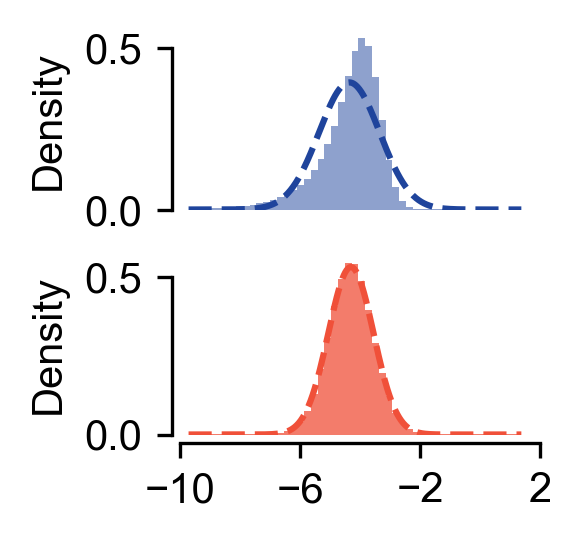

/tmp/ipykernel_3872036/177126318.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(get_checkpoint_name(exp_results, seed, epoch_idx),


In [14]:
eg_exp_results = results_dict.eg_log_normal
gd_exp_results = results_dict.gd_log_normal

fig = plot_weight_hists(eg_exp_results, gd_exp_results, eg_key="rnn.base_layer.weight_hh", epoch_idx=6, 
                  zero_th=6e-5, log_weights=True, log_y_scale=False, kde=False, stat='density',
                 gaussian_approx=True, xlims_step=(-10, 2, 4))  # 1e-5 for log weights

fig.savefig("figs/fig1/1e_ln_weights_hists.pdf", bbox_inches="tight", transparent=True)
# save the data used to make the plot, assume function is available
data_to_save = {
    "eg_log_normal": {},
    "gd_log_normal": {}
}
for exp_name, exp_results in zip(["eg_log_normal", "gd_log_normal"], [eg_exp_results, gd_exp_results]):
    seed = "seed_7"
    epoch_idx = 6
    ckpt = torch.load(get_checkpoint_name(exp_results, seed, epoch_idx),
                             map_location=torch.device('cpu'))
    key = "rnn.base_layer.weight_hh" if exp_name.startswith("eg") else "rnn.weight_hh"
    arr = ckpt[key].flatten().detach().numpy()
    arr = np.abs(arr)
    arr = arr[arr > 6e-5]
    log_arr = np.log(arr)
    data_to_save[exp_name]['weights'] = log_arr
np.savez("plot_data/fig1e_ln_weights_hists_data.npz", **data_to_save)   

Todo: suppress / correct warnings!
<class 'matplotlib.figure.Figure'>
/network/projects/_groups/linclab_users/eg/modcog/exp8_final_combined/eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss/seed_7/epoch_ckpts/model_6.pt


/tmp/ipykernel_833038/2938238977.py:31: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gd_ckpt = torch.load(get_checkpoint_name(gd_exp_results, seed, epoch_idx),
/tmp/ipykern

x_lims are (-10.01, 2.0)


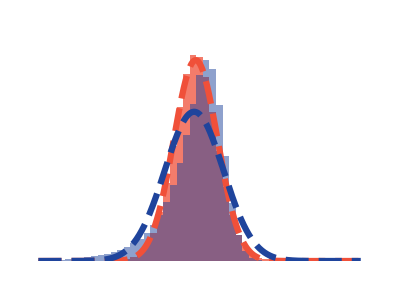

In [52]:
eg_exp_results = results_dict.eg_log_normal
gd_exp_results = results_dict.gd_log_normal

fig = plot_weight_hists(eg_exp_results, gd_exp_results, eg_key="rnn.base_layer.weight_hh", epoch_idx=6, 
                        zero_th=6e-5, log_weights=True, log_y_scale=False, kde=False, stat='density',
                        gaussian_approx=True, xlims_step=(-10, 2, 4), ylims_step=(0,0.61,0.2), 
                        seperate_plots=False, figsize_tuple= (1.5, 1), axis_off=True)  # 1e-5 for log weights

# plt.axis("off")
fig.savefig("figs/fig2/1e_ln_weights_hists_samefig.pdf", bbox_inches="tight", transparent=True)

In [15]:
# z-score and then plot mean cdf + individual lines + Gaussian cdf
def get_param_arrs(eg_exp_results, gd_exp_results, eg_key, epoch_idx, log_weights=True, zero_th=None):
    if zero_th is not None: print("Zero threshold not implemented")
    seed_keys = [k for k in eg_exp_results.keys() if k.startswith("seed")]
    gd_arr_dict = {}
    eg_arr_dict = {}
    for seed in seed_keys:#,"seed_6","seed_7","seed_8","seed_9"]:
        gd_ckpt = torch.load(get_checkpoint_name(gd_exp_results, seed, epoch_idx),
                                map_location=torch.device('cpu'))
        
        eg_ckpt = torch.load(get_checkpoint_name(eg_exp_results, seed, epoch_idx),
                                map_location=torch.device('cpu'))
        
        gd_key = eg_key.replace("base_layer.", "")

        gd_arr = gd_ckpt[gd_key].flatten().detach().numpy()
        eg_arr = eg_ckpt[eg_key].flatten().detach().numpy()

        gd_arr = np.abs(gd_arr)
        eg_arr = np.abs(eg_arr)

        # commented out bec of concat failing at end
        # replace with
        # if zero_th is not None:
        #     gd_arr = gd_arr[gd_arr > zero_th]
        #     eg_arr = eg_arr[eg_arr > zero_th]

        if log_weights:
            gd_arr = np.log(gd_arr + 1e-9 * (gd_arr == 0))
            eg_arr = np.log(eg_arr + 1e-9 * (eg_arr == 0))

        gd_arr_dict[seed] = gd_arr[:,None]
        eg_arr_dict[seed] = eg_arr[:,None]

    gd_arr = np.concatenate(list(gd_arr_dict.values()), axis=1)
    eg_arr = np.concatenate(list(eg_arr_dict.values()), axis=1)
    return eg_arr, gd_arr

def z_score_arr(arr, axis=0):
    """axis 0 to z-score each column seperately"""
    mean = np.mean(arr, axis=axis)
    std = np.std(arr, axis=axis)
    return (arr - mean) / std


eg_key="rnn.base_layer.weight_hh"
epoch_idx = 6

eg_arr, gd_arr = get_param_arrs(eg_exp_results, gd_exp_results, eg_key, epoch_idx, zero_th=6e-5)

# note not removing zero thresholds, so not same scale
#print(np.sort(eg_arr[:,1]))

eg_arr_z = z_score_arr(eg_arr, axis=0)
gd_arr_z = z_score_arr(gd_arr, axis=0)

#print(np.sort(eg_arr_z[:,1]))

# Verify
print("Mean of each column after z-scoring (should be close to 0):")
print(np.mean(eg_arr_z, axis=0))
print("Standard deviation of each column after z-scoring (should be 1):")
print(np.std(eg_arr_z, axis=0))


Zero threshold not implemented


/tmp/ipykernel_3872036/1517090163.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gd_ckpt = torch.load(get_checkpoint_name(gd_exp_results, seed, epoch_idx),
/tmp/ipykern

Mean of each column after z-scoring (should be close to 0):
[ 5.73396856e-13 -1.11868110e-14 -2.64134379e-13  5.29740358e-13
 -3.22799441e-13]
Standard deviation of each column after z-scoring (should be 1):
[1. 1. 1. 1. 1.]


# KS-test for that

In [16]:
from scipy import stats

In [17]:
gd_stat = np.zeros(gd_arr_z.shape[1])
eg_stat = np.zeros(gd_arr_z.shape[1])

for seed in range(gd_arr_z.shape[1]):
    res_gd = stats.kstest(gd_arr_z[:, seed], stats.norm.cdf)
    res_eg = stats.kstest(eg_arr_z[:, seed], stats.norm.cdf)
    
    print(f'seed {seed}')
    print(f'GD\n{res_gd}')
    print(f'EG\n{res_eg}')
    
    gd_stat[seed] = res_gd.statistic
    eg_stat[seed] = res_eg.statistic

seed 0
GD
KstestResult(statistic=np.float64(0.09928627674634949), pvalue=np.float64(0.0), statistic_location=np.float64(-0.10553846027710914), statistic_sign=np.int8(-1))
EG
KstestResult(statistic=np.float64(0.011093971929739183), pvalue=np.float64(0.0), statistic_location=np.float64(-0.7489811218636688), statistic_sign=np.int8(-1))
seed 1
GD
KstestResult(statistic=np.float64(0.09957551684989413), pvalue=np.float64(0.0), statistic_location=np.float64(-0.10607133559239203), statistic_sign=np.int8(-1))
EG
KstestResult(statistic=np.float64(0.011132628395846667), pvalue=np.float64(0.0), statistic_location=np.float64(-0.7501248790024476), statistic_sign=np.int8(-1))
seed 2
GD
KstestResult(statistic=np.float64(0.09967851383137682), pvalue=np.float64(0.0), statistic_location=np.float64(-0.1110328368637615), statistic_sign=np.int8(-1))
EG
KstestResult(statistic=np.float64(0.01107419648861585), pvalue=np.float64(0.0), statistic_location=np.float64(-0.7509408856099019), statistic_sign=np.int8(-1

In [18]:
ttest_res = stats.ttest_ind(gd_stat, eg_stat, equal_var=True, alternative='two-sided')
print(f'GD vs EG mean difference t-test; two-sided, different variance Welch’s t-test\n\t{ttest_res}')

ttest_res = stats.ttest_1samp(gd_stat, popmean=0, alternative='two-sided')
print(f'1 sample t-test for GD being nonzero\n\t{ttest_res}')

ttest_res = stats.ttest_1samp(gd_stat, popmean=0, alternative='two-sided')
print(f'1 sample t-test for EG being nonzero\n\t{ttest_res}')

print(f'mean KS stat ratio gd/eg\n\t{gd_stat.mean() / eg_stat.mean()}')

GD vs EG mean difference t-test; two-sided, different variance Welch’s t-test
	TtestResult(statistic=np.float64(799.908291497592), pvalue=np.float64(6.681544833902823e-21), df=np.float64(8.0))
1 sample t-test for GD being nonzero
	TtestResult(statistic=np.float64(962.0842033801381), pvalue=np.float64(7.0031880237182265e-12), df=np.int64(4))
1 sample t-test for EG being nonzero
	TtestResult(statistic=np.float64(962.0842033801381), pvalue=np.float64(7.0031880237182265e-12), df=np.int64(4))
mean KS stat ratio gd/eg
	9.01676317066089


(5,)
0.09958244659698966 0.00020701399367565066
(5,)
0.011044145744119693 7.842437914235691e-05


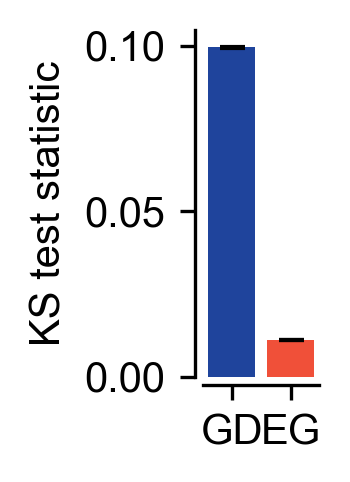

In [20]:
# bar chart showing final accuracy across the different weight distributions

plt.figure(figsize=(0.5,1.5), dpi = 300)
exp_labels = ["GD", "EG"]
colours = [results_dict.gd_log_normal.c, results_dict.eg_log_normal.c]
key = "test_Dec_Acc"
means = []
std_devs = []
for array in [gd_stat, eg_stat]:
    print(array.shape)
    means.append(array.mean())
    std_devs.append(array.std())
    print(array.mean(), array.std())

plt.bar(exp_labels, means, yerr=std_devs, color=colours, capsize=3,width=0.8 )
sns.despine(offset=2)

plt.ylabel("KS test statistic")

plt.savefig("figs/fig1/1e_KS_cdf_ttest.pdf", bbox_inches="tight", transparent=True)

# save the data used to make the bar plot
data_to_save = {}
for exp_name, array in zip(["gd_log_normal", "eg_log_normal"], [gd_stat, eg_stat]):
    mean = array.mean()
    std_dev = array.std()
    data_to_save[exp_name] = {
        "mean": mean,
        "std": std_dev
    }
np.savez("plot_data/fig1e_KS_cdf_ttest_data.npz", **data_to_save)

# Continuing with old plots

In [23]:
eg_arr_z = np.sort(eg_arr_z, axis=0)
gd_arr_z = np.sort(gd_arr_z, axis=0)

In [24]:
eg_arr_z.shape

(6250000, 5)

In [25]:
eg_arr_z.shape

(6250000, 5)

In [26]:
points = np.linspace(-3, 3, 100)
#weights, seeds, points
gd_cdfs = (gd_arr_z[:, :, None] <= points[None, None, :]).mean(axis=0)
eg_cdfs = (eg_arr_z[:, :, None] <= points[None, None, :]).mean(axis=0)

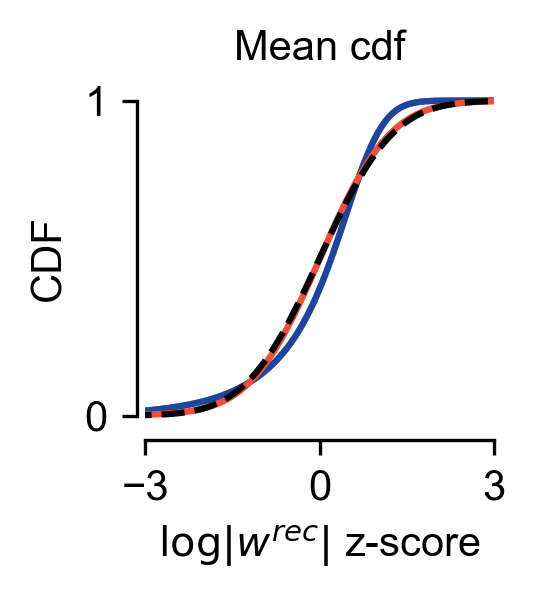

In [27]:
from scipy.stats import norm

xlims = (-3, 3)
ylims = (0,1)
normal_x = np.linspace(-5, 5, 500)
normal_cdf = norm.cdf(normal_x)

fig = plt.figure(figsize=(1.5, 1.5), dpi=300)

# individual ones
plt.plot(points[None, :].repeat(5, axis=0).T, gd_cdfs.T, color=gd_exp_results.c, alpha=0.2)
plt.plot(points[None, :].repeat(5, axis=0).T, eg_cdfs.T, color=eg_exp_results.c, alpha=0.2)

plt.plot(points, gd_cdfs.mean(axis=0), label='GD', color=gd_exp_results.c)
plt.plot(points, eg_cdfs.mean(axis=0), label='EG', color=eg_exp_results.c)

plt.plot(normal_x, normal_cdf, label='Normal', color='black', linestyle='--')
# means
# eg_mean =np.mean(eg_arr_z, axis=1)
# gd_mean = np.mean(gd_arr_z, axis=1)
# cdf_eg = np.arange(1, len(eg_mean) + 1) / len(eg_mean)
# cdf_gd = np.arange(1, len(gd_mean) + 1) / len(gd_mean)
# plt.plot(eg_mean, cdf_eg, label='EG', color=eg_exp_results.c)
# plt.plot(gd_mean, cdf_gd, label='GD', color=gd_exp_results.c)



#plt.xlim(xlims[0], xlims[1])

ax = plt.gca()
ax.set_xticks([xlims[0],0, xlims[1]])  
ax.set_xlim(xlims)
ax.set_yticks([ylims[0], ylims[1]]) 
#ax.set_ylim(ylims)

# for col_i in range(eg_arr_z.shape[1]):
#     plt.plot(eg_arr_z[:,col_i], cdf_eg, alpha=0.1, color=eg_exp_results.c)
#     plt.plot(gd_arr_z[:,col_i], cdf_gd, alpha=0.1, color=gd_exp_results.c)


plt.title("Mean cdf")
plt.xlabel(r"$\log |w^{rec}|$ z-score")
plt.ylabel('CDF')
sns.despine(offset=2, trim=True)
#plt.legend()
fig.savefig("figs/fig1/1e_ln_weights_cdf.pdf", bbox_inches="tight", transparent=True)

In [31]:
# Plots for fig2 and the pruning

import scipy.stats as stats

# calculate kurtois and skewness
print(f"EG: std {np.std(eg_arr)}, skew {stats.skew(eg_arr)}, kurtosis  {stats.kurtosis(eg_arr)}")
print(f"GD: std {np.std(gd_arr)}, skew {stats.skew(gd_arr)}, kurtosis  {stats.kurtosis(gd_arr)}")

EG: std 0.7589514410843857, skew [-0.46740578 -0.43725867 -0.40135304 -0.44498993 -0.40929958], kurtosis  [12.5708892  10.40599609  7.98734922  9.77011896  9.42588967]
GD: std 1.0494704517001676, skew [-1.59683365 -1.59895592 -1.60859745 -1.5986885  -1.60036819], kurtosis  [4.68216158 4.68333213 4.79143835 4.70251008 4.68777729]


EG threshold: -3.0887242634852496, GD threshold: -3.1051266550757837
EG right tail: (1562500,), GD right tail: (1562500,)
EG: std 0.33177565317815033, skew 2.1876383585165144, kurtosis  8.651200300025458
GD: std 0.20364546207154752, skew 1.5034109633046968, kurtosis  2.919539562969021


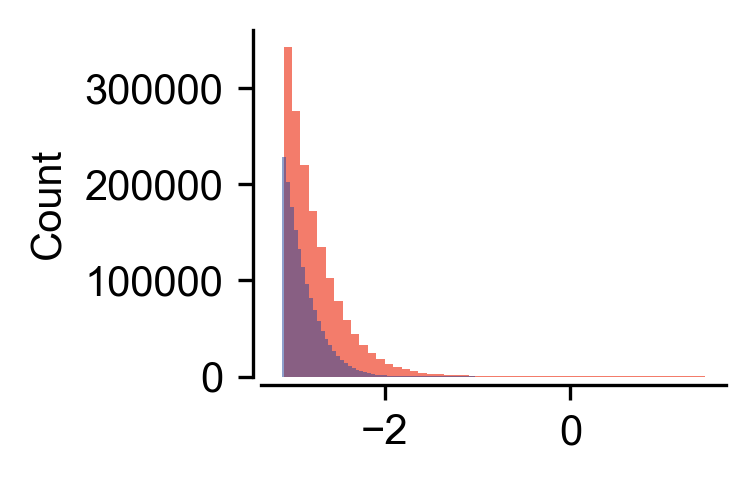

In [29]:


eg_threshold = np.percentile(eg_arr, 95)  # 95th percentile as the threshold
gd_threshold = np.percentile(gd_arr, 95)

print(f"EG threshold: {eg_threshold}, GD threshold: {gd_threshold}")

eg_right_tail = eg_arr[eg_arr > eg_threshold]
gd_right_tail = gd_arr[gd_arr > gd_threshold]

print(f"EG right tail: {eg_right_tail.shape}, GD right tail: {gd_right_tail.shape}")

# plot the right tails
plt.figure(figsize=(2,1.5), dpi = 300)
sns.histplot(eg_right_tail, bins = 50, kde=False, stat='count', color=eg_exp_results.c, ec=None,
            label='EG')
sns.histplot(gd_right_tail, bins = 50, kde=False, stat='count', color=gd_exp_results.c, ec=None, alpha=0.5,
            label='GD')
sns.despine(offset=2, trim=False)

# calculate kurtois and skewness
print(f"EG: std {np.std(eg_right_tail)}, skew {stats.skew(eg_right_tail)}, kurtosis  {stats.kurtosis(eg_right_tail)}")
print(f"GD: std {np.std(gd_right_tail)}, skew {stats.skew(gd_right_tail)}, kurtosis  {stats.kurtosis(gd_right_tail)}")

Todo: suppress / correct warnings!
<class 'matplotlib.figure.Figure'>
/network/projects/_groups/linclab_users/eg/modcog/exp8_final_combined/eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss/seed_7/epoch_ckpts/model_6.pt
x_lims are (-2.51, 0.5)


/tmp/ipykernel_833038/2938238977.py:31: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gd_ckpt = torch.load(get_checkpoint_name(gd_exp_results, seed, epoch_idx),
/tmp/ipykern

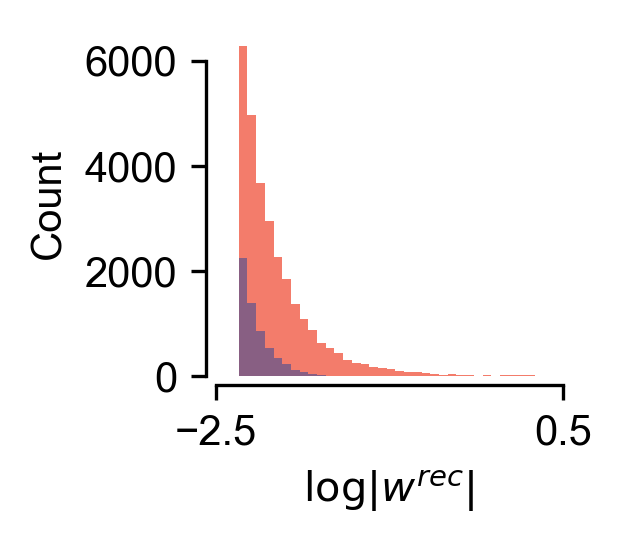

In [56]:
fig = plot_weight_hists(eg_exp_results, gd_exp_results, eg_key="rnn.base_layer.weight_hh", epoch_idx=6, 
                  zero_th=0.1, log_weights=True, log_y_scale=False, kde=False, stat='count', seperate_plots=False,
                  xlims_step=(-2.5,0.5,3), figsize_tuple= (1.5, 1.5))  # 1e-5 for log weights

fig.savefig("figs/fig2/1a_eg_gd_tails.pdf", bbox_inches="tight", transparent=True)

Todo: suppress / correct warnings!
<class 'matplotlib.figure.Figure'>
/network/projects/_groups/linclab_users/eg/modcog/exp8_final_combined/eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss/seed_7/epoch_ckpts/model_6.pt
x_lims are (-2.51, 0.5)


/tmp/ipykernel_833038/2938238977.py:31: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gd_ckpt = torch.load(get_checkpoint_name(gd_exp_results, seed, epoch_idx),
/tmp/ipykern

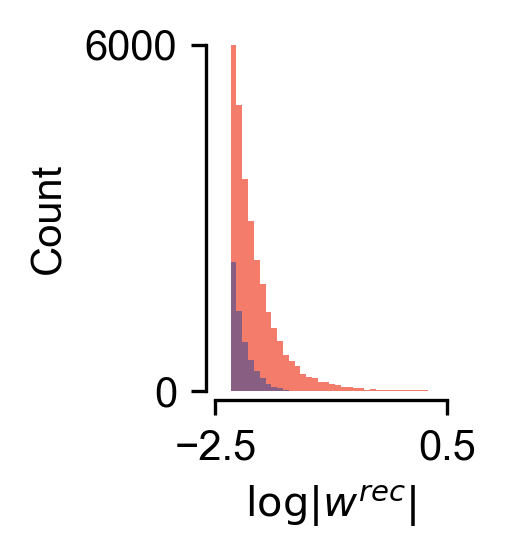

In [62]:
fig = plot_weight_hists(eg_exp_results, gd_exp_results, eg_key="rnn.base_layer.weight_hh", epoch_idx=6, 
                  zero_th=0.1, log_weights=True, log_y_scale=False, kde=False, stat='count', seperate_plots=False,
                  xlims_step=(-2.5,0.5,3), ylims_step=(0,6000,6000), figsize_tuple= (1, 1.5))  # 1e-5 for log weights

fig.savefig("figs/fig2/1a_eg_gd_tails.pdf", bbox_inches="tight", transparent=True)

# Below is old and Plots for supplementary etc 



0.9913247585296631 0.0006420378157498704 (6000, 5)
0.9910959601402283 0.0004051804838907522 (6000, 5)


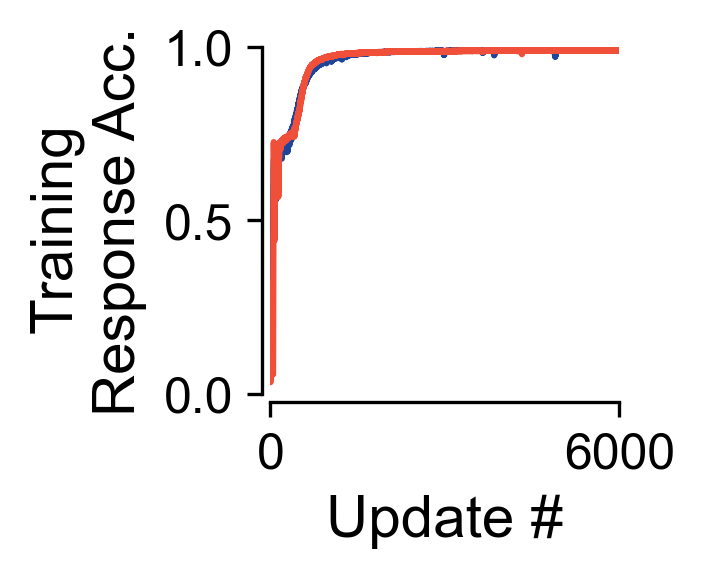

In [43]:
exp_strs = ["gd_log_normal", "eg_log_normal"]
key = "Acc"
xlims = (0, 6000)
ylims = (0, 1)

plt.figure(figsize=(1.5,1.5), dpi = 300)
for exp_name in exp_strs:
    array = results_dict[exp_name].train_results[key].mean(axis=1)
    std_dev = results_dict[exp_name].train_results[key].std(axis=1)
    print(array[-1], std_dev[-1], results_dict[exp_name].train_results[key].shape)
    n_updates = array.shape[0]
    plt.plot(np.arange(1,n_updates+1), array, c=results_dict[exp_name].c, label=exp_name)
    # plt.fill_between(np.arange(1,n_updates+1), array-std_dev, array+std_dev, color=results_dict[exp_name].c, alpha=0.2)
ax = plt.gca()

# Set the tick locations
logx = False
logy = False
if logx: plt.xscale("log")
if logy: plt.yscale("log")

y_step = 0.5
x_step = 6000
ax.set_xticks(np.arange(xlims[0],xlims[1]+x_step, x_step))  
ax.set_yticks(np.arange(ylims[0],ylims[1]+y_step, y_step)) 

ax.set_xlim(xlims)
ax.set_ylim(ylims)

# sns.despine(offset=2, trim=True)

plt.xlabel("Update #")
plt.ylabel("Training \nResponse Acc.", rotation=90)

#sns.despine()
sns.despine(offset=2, trim=True)

# plt.tight_layout()
# plt.savefig("figs/fig1/1c_response_acc.pdf", bbox_inches="tight")
# plt.savefig("figs/fig1/1c_decacc_training_uni.png", bbox_inches="tight")

In [44]:
exp_strs = ["gd_uniform", "gd_normal", "gd_log_normal", "eg_uniform", "eg_normal", "eg_log_normal"]
key = "test_Dec_Acc"

data = {'exp_name': [],
        key: []}

colours = []

for exp_name in exp_strs:
    array = results_dict[exp_name].eval_results[key][-1,:].ravel() # last epoch, all seeds
    for i in range(array.shape[0]):
        #print(exp_name, array[i])
        data['exp_name'].append(exp_name)
        data[key].append(array[i])
        colours.append(results_dict[exp_name].c)

df = pd.DataFrame(data)
df.head()

,exp_name,test_Dec_Acc
0,gd_uniform,0.983945
1,gd_uniform,0.984016
2,gd_uniform,0.983963
3,gd_uniform,0.983875
4,gd_uniform,0.983993


/network/scratch/r/roman.pogodin/.conda/ngym2/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/network/scratch/r/roman.pogodin/.conda/ngym2/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/network/scratch/r/roman.pogodin/.conda/ngym2/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/network/scratch/r/roman.pogodin/.conda/ngym2/lib/python3.9/si

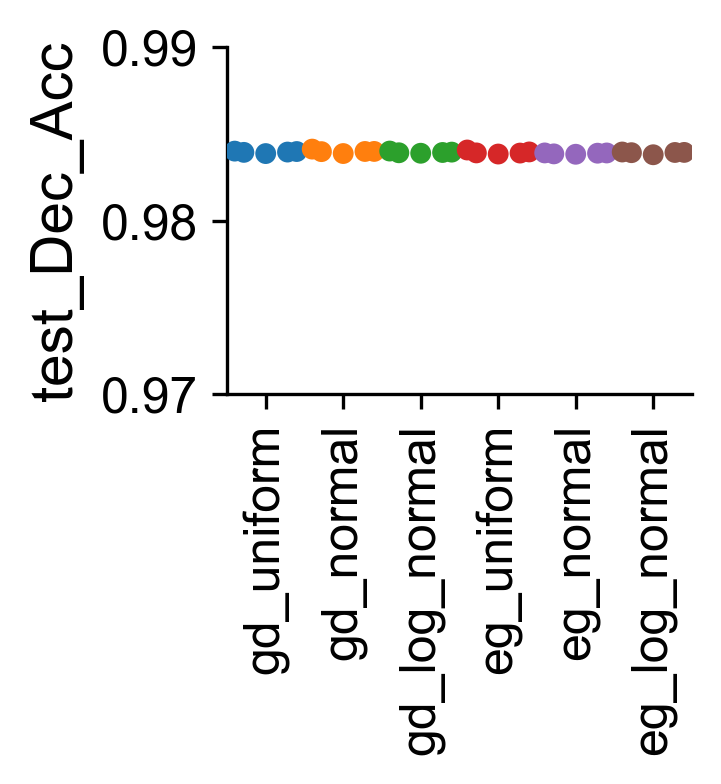

In [45]:
# # # Create bar plot
plt.figure(figsize=(2,1.5), dpi = 300)
# bar_values = df.groupby('exp_name')[key].mean().reindex(exp_strs)
# print(bar_values)
# bar_positions = np.arange(len(exp_strs))

# plt.bar(bar_positions, bar_values, color='lightblue', edgecolor='black')
# plt.xticks(bar_positions, exp_strs)
plt.ylim(0.97, 0.99)

# Create swarm plot
sns.swarmplot(x='exp_name', y=key, data=df, hue=colours)#color='black', zorder=2)

#plt.xlabel(#)
plt.ylabel(key)
#plt.title('Final Test response Accuracy')
plt.xticks(rotation=90)
plt.legend().remove()
plt.xlabel("")

sns.despine()

plt.savefig("figs/fig1/s1a_decacc_test.pdf", bbox_inches="tight")
plt.savefig("figs/fig1/s1a_decacc_test.png", bbox_inches="tight")


0.6380996346473694 0.0041203728536927 (6000, 5)
0.6373740673065186 0.0039035043303939105 (6000, 5)
0.6391274213790894 0.0032175770371147398 (6000, 5)
0.6345999956130981 0.002309498509199426 (6000, 5)
0.636611032485962 0.002234914019194351 (6000, 5)
0.6342073321342468 0.002187611197692005 (6000, 5)


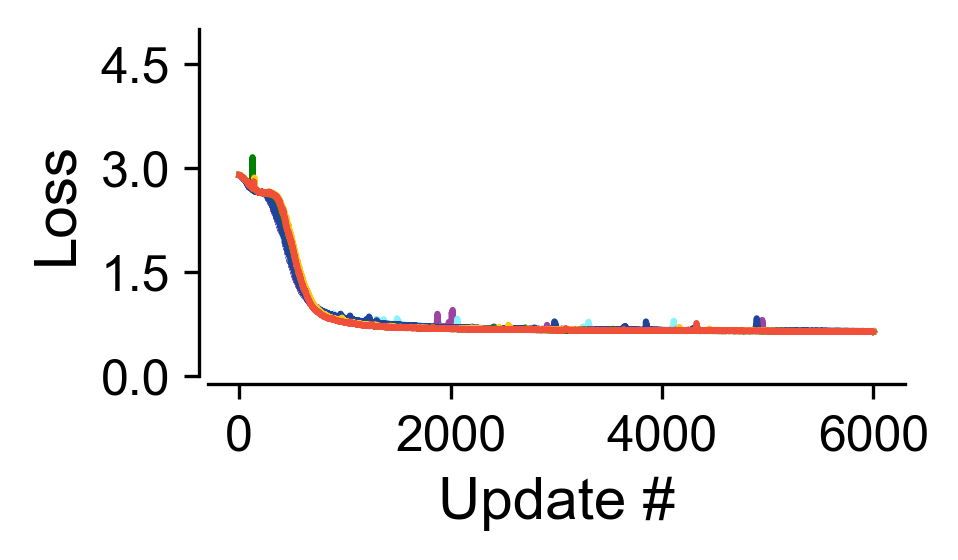

In [46]:
exp_strs = ["gd_uniform", "gd_normal", "gd_log_normal", "eg_uniform", "eg_normal", "eg_log_normal"]
key = "Loss"
xlims = (0, 6000)
ylims = (0, 5)

plt.figure(figsize=(3,1.5), dpi = 300)
for exp_name in exp_strs:
    array = results_dict[exp_name].train_results[key].mean(axis=1)
    std_dev = results_dict[exp_name].train_results[key].std(axis=1)
    print(array[-1], std_dev[-1], results_dict[exp_name].train_results[key].shape)
    n_updates = array.shape[0]
    plt.plot(np.arange(1,n_updates+1), array, c=results_dict[exp_name].c, label=exp_name)

    #legend_patches.append(patches.Rectangle((0,0), 1, 1, facecolor=colours[i], label=labels[i]))

ax = plt.gca()

# Set the tick locations
logx = False
logy = False
if logx:    
    plt.xscale("log")
if logy:    
    plt.yscale("log")
# x_step = 2000
# y_step = 0.5
# ax.set_xticks(np.arange(xlims[0],xlims[1]+x_step, x_step))
y_step = 1.5  
ax.set_yticks(np.arange(ylims[0],ylims[1]+y_step, y_step)) 

# ax.set_xlim(xlims)
ax.set_ylim(ylims)

# sns.despine(offset=2, trim=True)

plt.xlabel("Update #")
plt.ylabel("Loss")
#sns.despine()
sns.despine(offset=2, trim=False)

plt.savefig("figs/fig1_loss_training.pdf", bbox_inches="tight")
plt.savefig("figs/fig1_loss_training.png", bbox_inches="tight")

results_dict.eg_uniform# 2. Analyse weight dists from saved checkpoints

In [47]:
results_dict.eg_uniform.train_results.keys()

dict_keys(['Loss', 'Loss_auc', 'Mse_fixation', 'Acc', 'Dec Acc', 'lr', 'grads_norm_before_clip', 'grads_norm_after_clip', 'rnn.weight_ih', 'rnn.weight_hh', 'fc.weight', 'rnn.base_layer.weight_ih_sflips', 'rnn.base_layer.weight_hh_sflips', 'fc.base_layer.weight_sflips', 'h_norm'])

In [48]:
results_dict.eg_uniform.train_results["fc.weight"].keys()

dict_keys(['const', 'slope', 'pconst', 'pslope', 'r2'])

In [49]:
results_dict.eg_uniform.train_results["rnn.weight_hh"].keys()

dict_keys(['const', 'slope', 'pconst', 'pslope', 'r2'])

In [50]:
results_dict.eg_uniform.train_results["rnn.weight_ih"].keys()

dict_keys(['const', 'slope', 'pconst', 'pslope', 'r2'])

## New plots

In [51]:
def plot_mean_r2(eg_results, gd_results):
    # results_dict.eg_log_normal etc
    eg = eg_results.seed_5.train_results["rnn.weight_hh"]['r2'][None, :]
    gd = gd_results.seed_5.train_results["rnn.weight_hh"]['r2'][None, :]
    
    for seed in [6, 7, 8, 9]:
        eg = np.concatenate((eg, eval(f'eg_results.seed_{seed}.train_results["rnn.weight_hh"]["r2"][None, :]')), axis=0)
        gd = np.concatenate((gd, eval(f'gd_results.seed_{seed}.train_results["rnn.weight_hh"]["r2"][None, :]')), axis=0)
        
    plt.figure(figsize=(3,1.5), dpi = 300)
    
    plt.plot(np.nanmean(eg, axis=0), color=eg_results.c, label='EG')
    plt.fill_between(np.arange(eg.shape[1]), 
                     np.nanmean(eg, axis=0) - np.nanstd(eg, axis=0),
                     np.nanmean(eg, axis=0) + np.nanstd(eg, axis=0),
                     color=eg_results.c, alpha=0.5)
    plt.plot(np.nanmean(gd, axis=0), color=gd_results.c, label='GD')
    plt.fill_between(np.arange(gd.shape[1]), 
                     np.nanmean(gd, axis=0) - np.nanstd(gd, axis=0),
                     np.nanmean(gd, axis=0) + np.nanstd(gd, axis=0),
                     color=gd_results.c, alpha=0.5)

    plt.ylabel(r'$R^2$')
    plt.xlabel('iter')
    plt.legend()
    plt.show()

/tmp/ipykernel_783431/2935704695.py:12: RuntimeWarning: Mean of empty slice
  plt.plot(np.nanmean(eg, axis=0), color=eg_results.c, label='EG')
/tmp/ipykernel_783431/2935704695.py:14: RuntimeWarning: Mean of empty slice
  np.nanmean(eg, axis=0) - np.nanstd(eg, axis=0),
/network/scratch/r/roman.pogodin/.conda/ngym2/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_783431/2935704695.py:15: RuntimeWarning: Mean of empty slice
  np.nanmean(eg, axis=0) + np.nanstd(eg, axis=0),
/tmp/ipykernel_783431/2935704695.py:17: RuntimeWarning: Mean of empty slice
  plt.plot(np.nanmean(gd, axis=0), color=gd_results.c, label='GD')
/tmp/ipykernel_783431/2935704695.py:19: RuntimeWarning: Mean of empty slice
  np.nanmean(gd, axis=0) - np.nanstd(gd, axis=0),
/tmp/ipykernel_783431/2935704695.py:20: RuntimeWarning: Mean of empty slice
  np.nanmean(gd, axis=0) + np.nanstd(gd, 

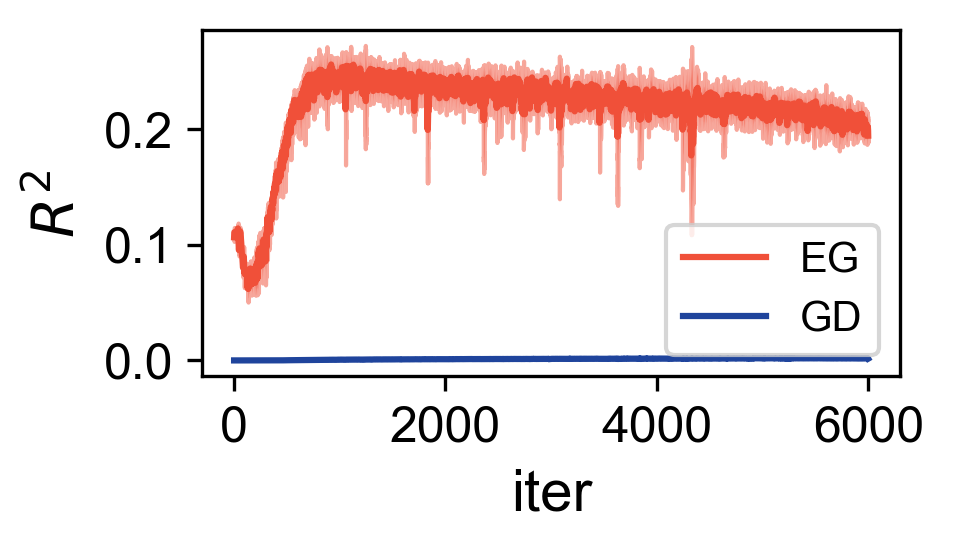

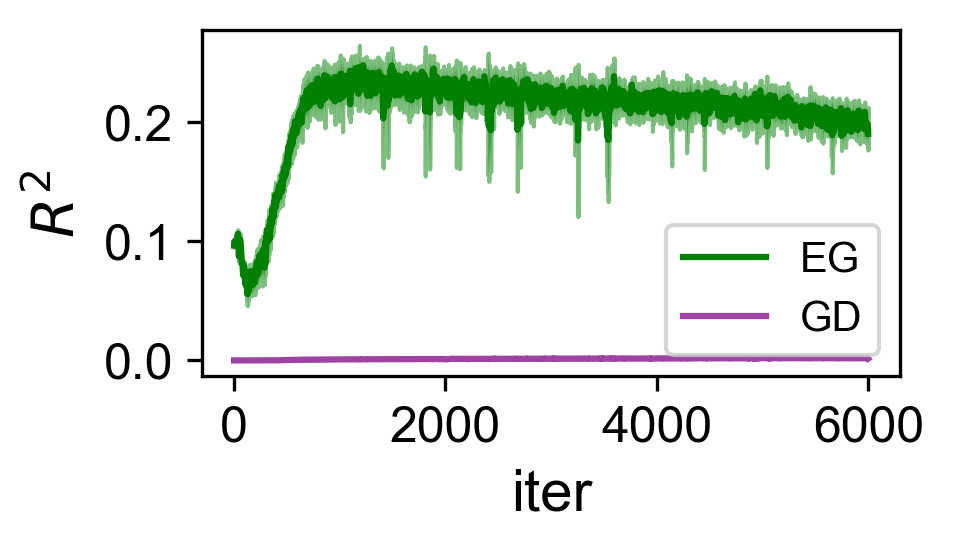

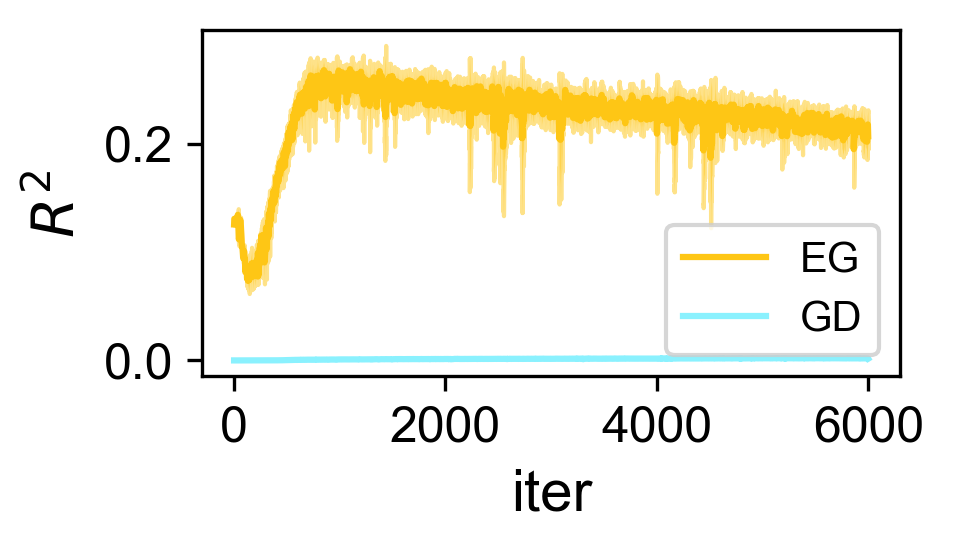

In [52]:
plot_mean_r2(results_dict.eg_log_normal, results_dict.gd_log_normal)
plot_mean_r2(results_dict.eg_uniform, results_dict.gd_uniform)
plot_mean_r2(results_dict.eg_normal, results_dict.gd_normal)

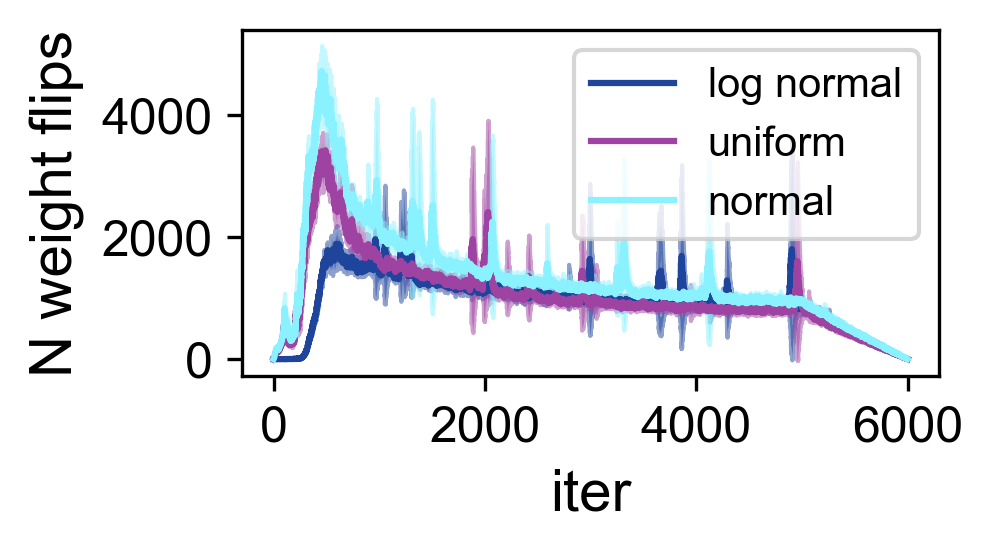

In [53]:
plt.figure(figsize=(3,1.5), dpi = 300)

n_iter = results_dict.gd_uniform.train_results['rnn.weight_hh_sflips'].shape[0]

def plot_mean(arr, label, c):
    plt.plot(arr.mean(axis=1), label=label, color=c)
    plt.fill_between(np.arange(n_iter), arr.mean(axis=1) - arr.std(axis=1), arr.mean(axis=1) + arr.std(axis=1),
                     alpha=0.5, color=c)

plot_mean(results_dict.gd_log_normal.train_results['rnn.weight_hh_sflips'], 'log normal', results_dict.gd_log_normal.c)
plot_mean(results_dict.gd_uniform.train_results['rnn.weight_hh_sflips'], 'uniform', results_dict.gd_uniform.c)
plot_mean(results_dict.gd_normal.train_results['rnn.weight_hh_sflips'], 'normal', results_dict.gd_normal.c)

plt.ylabel('N weight flips')
plt.xlabel('iter')
plt.legend()
plt.show()